In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder

In [46]:
df=pd.read_csv('C:/Users/medoc/OneDrive/Desktop/work/Machine/data/fifa19.csv')
df.head()

,Name,Age,Nationality,Overall,Potential,Club,Position,Crossing,Finishing,HeadingAccuracy,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,Value
0,L. Messi,31,Argentina,94,94,FC Barcelona,RF,84.0,95.0,70.0,...,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,110.5
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,ST,84.0,94.0,89.0,...,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,77.0
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,LW,79.0,87.0,62.0,...,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,118.5
3,De Gea,27,Spain,91,93,Manchester United,GK,17.0,13.0,21.0,...,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,72.0
4,K. De Bruyne,27,Belgium,91,92,Manchester City,RCM,93.0,82.0,55.0,...,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,102.0


In [47]:
df.describe()

,Age,Overall,Potential,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,Value
count,17955.000000,17955.000000,17955.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,...,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17955.000000
mean,25.095349,66.228237,71.323197,49.751885,45.586698,52.298878,58.717261,42.935500,55.420283,47.218630,...,48.546043,58.651868,47.262467,47.684202,45.644441,16.587536,16.365276,16.203105,16.356062,2.444530
std,4.659778,6.921015,6.139378,18.351445,19.511503,17.361599,14.673721,17.685432,18.899100,18.384605,...,15.685745,11.421007,19.872750,21.647299,21.271215,17.662332,16.875398,16.467295,16.989954,5.626715
min,16.000000,46.000000,48.000000,5.000000,2.000000,4.000000,7.000000,4.000000,4.000000,6.000000,...,5.000000,3.000000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.010000
25%,21.000000,62.000000,67.000000,38.000000,30.000000,44.000000,54.000000,30.000000,49.000000,34.000000,...,39.000000,51.000000,30.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,0.325000
50%,25.000000,66.000000,71.000000,54.000000,49.000000,56.000000,62.000000,44.000000,61.000000,49.000000,...,49.000000,60.000000,53.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,0.700000
75%,28.000000,71.000000,75.000000,64.000000,62.000000,64.000000,68.000000,57.000000,68.000000,62.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,2.100000
max,45.000000,94.000000,95.000000,93.000000,95.000000,94.000000,93.000000,90.000000,97.000000,94.000000,...,92.000000,96.000000,94.000000,93.000000,91.000000,90.000000,92.000000,91.000000,90.000000,118.500000


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17955 entries, 0 to 17954
Data columns (total 41 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             17955 non-null  object 
 1   Age              17955 non-null  int64  
 2   Nationality      17955 non-null  object 
 3   Overall          17955 non-null  int64  
 4   Potential        17955 non-null  int64  
 5   Club             17955 non-null  object 
 6   Position         17907 non-null  object 
 7   Crossing         17907 non-null  float64
 8   Finishing        17907 non-null  float64
 9   HeadingAccuracy  17907 non-null  float64
 10  ShortPassing     17907 non-null  float64
 11  Volleys          17907 non-null  float64
 12  Dribbling        17907 non-null  float64
 13  Curve            17907 non-null  float64
 14  FKAccuracy       17907 non-null  float64
 15  LongPassing      17907 non-null  float64
 16  BallControl      17907 non-null  float64
 17  Acceleration

In [49]:
df.isnull().sum()
df

,Name,Age,Nationality,Overall,Potential,Club,Position,Crossing,Finishing,HeadingAccuracy,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,Value
0,L. Messi,31,Argentina,94,94,FC Barcelona,RF,84.0,95.0,70.0,...,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,110.50
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,ST,84.0,94.0,89.0,...,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,77.00
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,LW,79.0,87.0,62.0,...,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,118.50
3,De Gea,27,Spain,91,93,Manchester United,GK,17.0,13.0,21.0,...,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,72.00
4,K. De Bruyne,27,Belgium,91,92,Manchester City,RCM,93.0,82.0,55.0,...,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,102.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17950,J. Lundstram,19,England,47,65,Crewe Alexandra,CM,34.0,38.0,40.0,...,43.0,45.0,40.0,48.0,47.0,10.0,13.0,7.0,8.0,0.06
17951,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,ST,23.0,52.0,52.0,...,43.0,42.0,22.0,15.0,19.0,10.0,9.0,9.0,5.0,0.06
17952,B. Worman,16,England,47,67,Cambridge United,ST,25.0,40.0,46.0,...,55.0,41.0,32.0,13.0,11.0,6.0,5.0,10.0,6.0,0.06
17953,D. Walker-Rice,17,England,47,66,Tranmere Rovers,RW,44.0,50.0,39.0,...,50.0,46.0,20.0,25.0,27.0,14.0,6.0,14.0,8.0,0.06


In [50]:
le = LabelEncoder()
df['Position'] = le.fit_transform(df['Position'])

df.head()

,Name,Age,Nationality,Overall,Potential,Club,Position,Crossing,Finishing,HeadingAccuracy,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,Value
0,L. Messi,31,Argentina,94,94,FC Barcelona,21,84.0,95.0,70.0,...,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,110.5
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,26,84.0,94.0,89.0,...,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,77.0
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,14,79.0,87.0,62.0,...,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,118.5
3,De Gea,27,Spain,91,93,Manchester United,5,17.0,13.0,21.0,...,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,72.0
4,K. De Bruyne,27,Belgium,91,92,Manchester City,19,93.0,82.0,55.0,...,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,102.0


In [51]:
df.drop(columns=['Name','Nationality','Club'],axis=1,inplace=True)

In [52]:
df = df.dropna()
df.isnull().sum()

Age                0
Overall            0
Potential          0
Position           0
Crossing           0
Finishing          0
HeadingAccuracy    0
ShortPassing       0
Volleys            0
Dribbling          0
Curve              0
FKAccuracy         0
LongPassing        0
BallControl        0
Acceleration       0
SprintSpeed        0
Agility            0
Reactions          0
Balance            0
ShotPower          0
Jumping            0
Stamina            0
Strength           0
LongShots          0
Aggression         0
Interceptions      0
Positioning        0
Vision             0
Penalties          0
Composure          0
Marking            0
StandingTackle     0
SlidingTackle      0
GKDiving           0
GKHandling         0
GKKicking          0
GKPositioning      0
Value              0
dtype: int64

<Axes: >

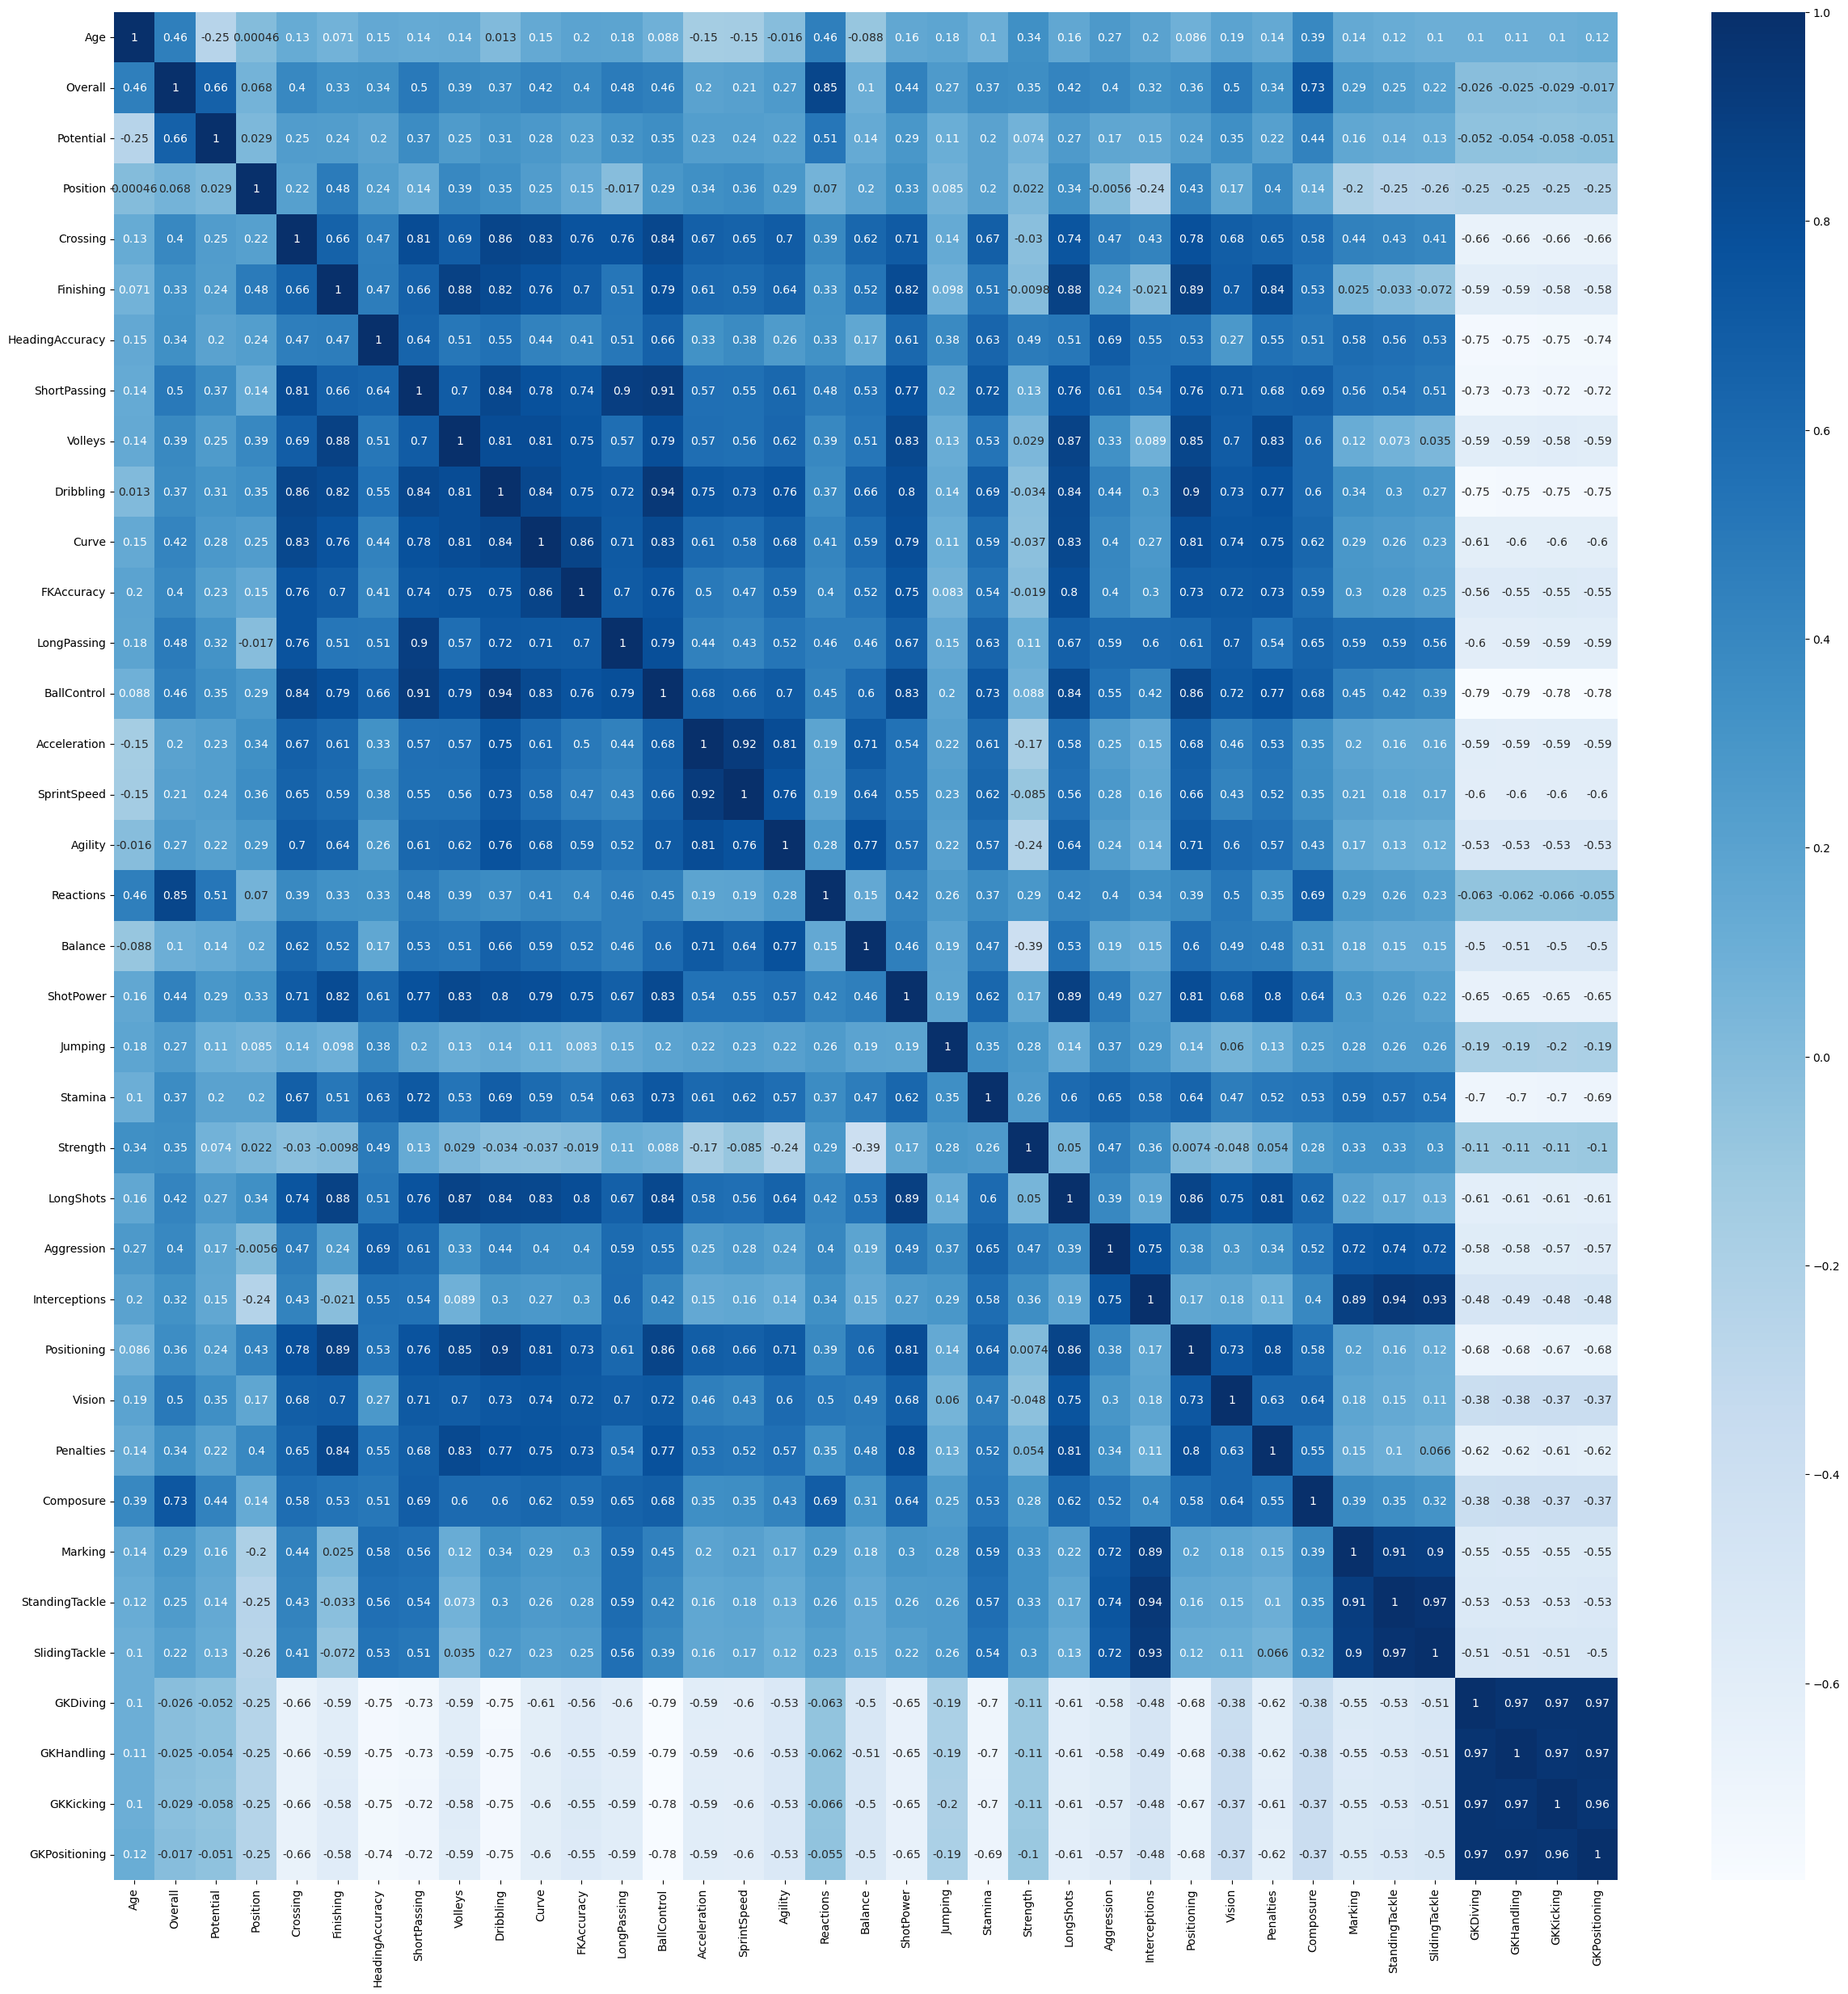

In [53]:
plt.figure(figsize=(30,30))
corr=df.drop('Value',axis=1).corr()
sns.heatmap(corr, annot=True, cmap="Blues")


In [54]:
X = df.drop('Value', axis=1)
y = df['Value']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [55]:
svr= SVR(kernel='rbf')
svr.fit(X_train, y_train)

SVR()

In [56]:
y_pred = svr.predict(X_test)

In [57]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mae)
print(r2)

0.537075629732124
0.7424536019932991
